In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the file generated by run_city_analysis.py
df_res = pd.read_excel("results/Final_Results.xlsx")
df_res.head()

,City,Category,Total_Activity_Corr,Arr_Global,Dep_Global,Arr_BadWeather,Dep_BadWeather,Arr_Workday,Dep_Workday,Arr_Weekend,Dep_Weekend,Arr_Workday_AM,Dep_Workday_PM
0,Ostrava-Svinov,Global,0.089154,0.047923,0.064512,0.041251,0.066141,0.052053,0.073032,0.034298,0.041249,0.062965,0.003432
1,Ostrava-Svinov,Regional,0.080303,0.034843,0.060605,0.024734,0.063442,0.038570,0.069751,0.021527,0.035131,0.076932,-0.006529
2,Ostrava-Svinov,LongDist,0.071888,0.040301,0.048841,0.043160,0.047849,0.042864,0.055001,0.032942,0.033786,-0.015246,0.014296
3,Ostrava hl.n.,Global,-0.269972,0.052367,-0.025322,NaN,NaN,0.070481,-0.032969,NaN,NaN,NaN,0.073563
4,Ostrava hl.n.,Regional,-0.207035,-0.012437,-0.013254,NaN,NaN,0.017483,-0.018564,NaN,NaN,NaN,0.089656


In [3]:
# We only want to compare Regional vs Long Distance
plot_df = df_res[df_res['Category'].isin(['Regional', 'LongDist'])].copy()

# Rename for nicer labels
plot_df.rename(columns={'Arr_Corr': 'Correlation', 'Category': 'Train Type'}, inplace=True)

In [4]:
plt.figure(figsize=(12, 7), dpi=150)
sns.set_theme(style="whitegrid")

# Create Bar Chart
ax = sns.barplot(
    data=plot_df,
    x='City',
    y='Correlation',
    hue='Train Type',
    palette='viridis',
    edgecolor='black',
    linewidth=1
)

# Styling
plt.axhline(0, color='black', linewidth=1)
plt.title("Impact of Train Arrivals on Bike Sharing Demand", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Pearson Correlation (r)", fontsize=12)
plt.xlabel("")
plt.legend(title='Train Category', loc='upper right')

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()
plt.savefig("Thesis_Chart_Correlation.png")
plt.show()

ValueError: Could not interpret value `Correlation` for `y`. An entry with this name does not appear in `data`.

<Figure size 1800x1050 with 0 Axes>

✅ Chart saved to Thesis_Chart_Correlation.png


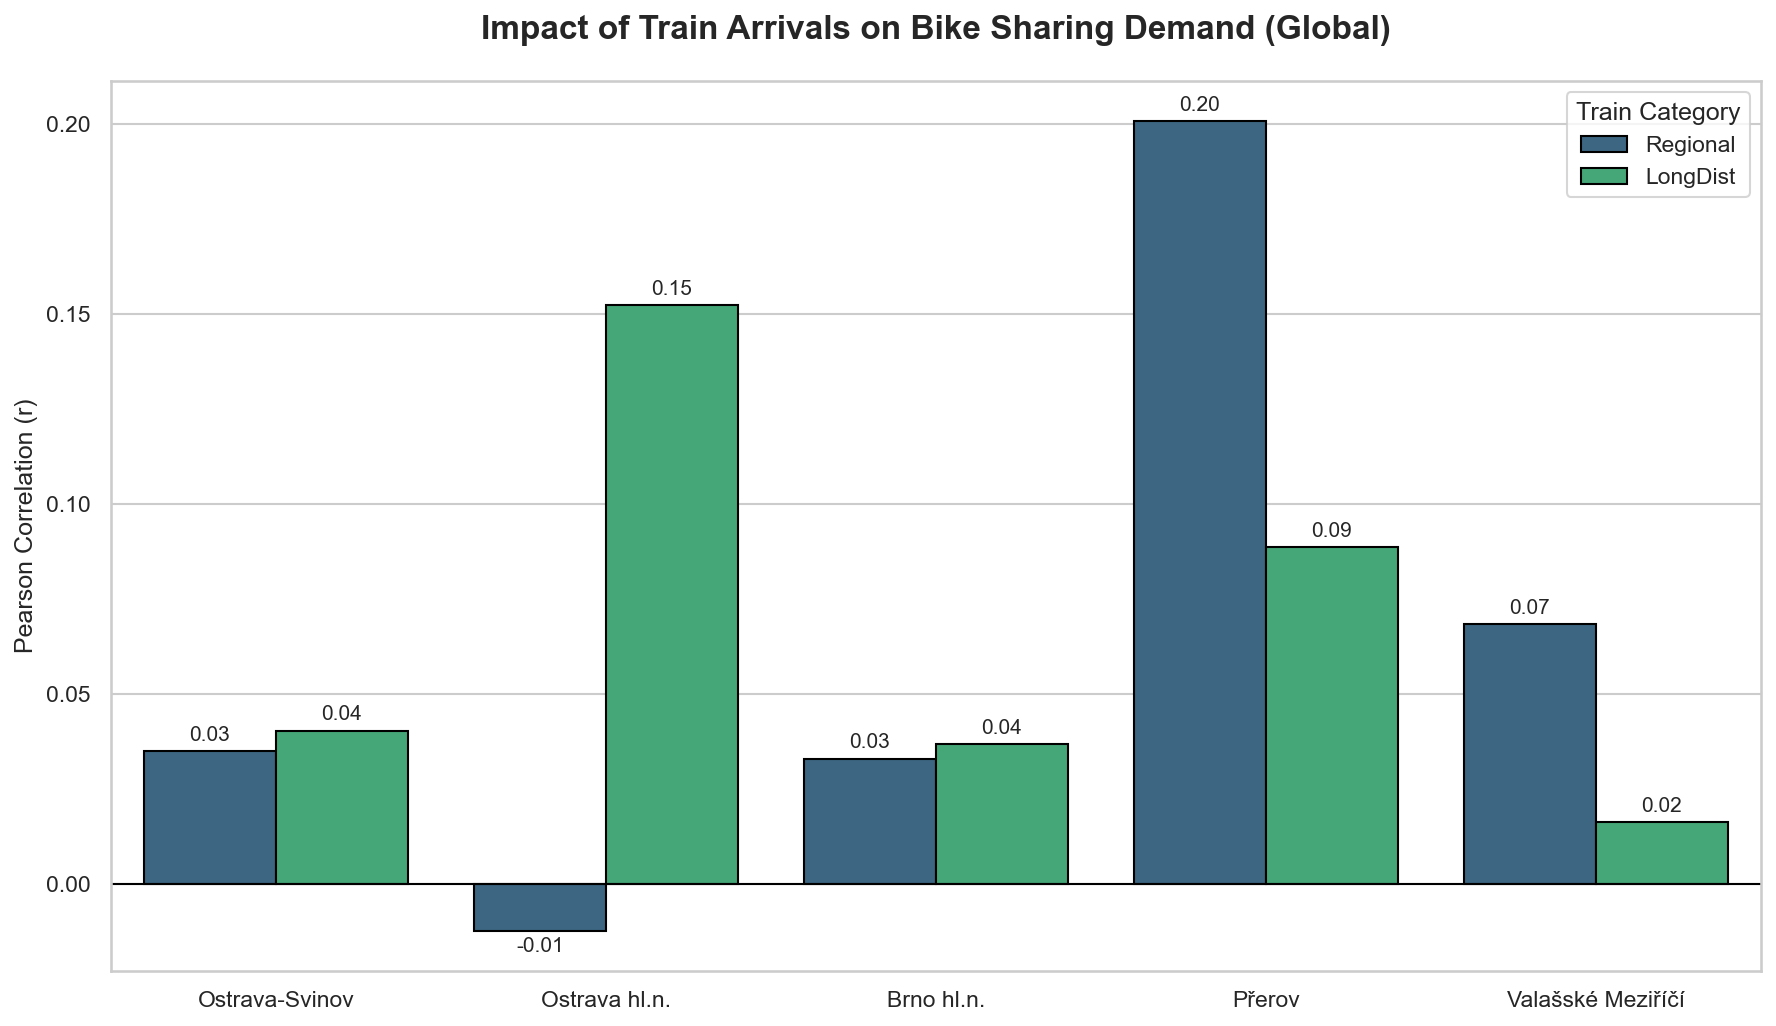

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# ==========================================
# 1. LOAD DATA
# ==========================================
file_path = "results/Final_Results.xlsx"

if not os.path.exists(file_path):
    print(f"❌ Error: {file_path} not found.")
    sys.exit()

df_res = pd.read_excel(file_path)

# Clean column names (remove hidden spaces)
df_res.columns = [str(c).strip() for c in df_res.columns]

# ==========================================
# 2. PROCESS DATA
# ==========================================
# Filter for specific categories
plot_df = df_res[df_res['Category'].isin(['Regional', 'LongDist'])].copy()

# --- FIX: Map the correct column name ---
# We use 'Arr_Global' because your goal is to show the impact of Arrivals
target_col = 'Arr_Global'

if target_col in plot_df.columns:
    plot_df.rename(columns={target_col: 'Correlation', 'Category': 'Train Type'}, inplace=True)
else:
    print(f"❌ Error: Column '{target_col}' not found.")
    print(f"   Available columns: {plot_df.columns.tolist()}")
    sys.exit()

# ==========================================
# 3. PLOT CHART
# ==========================================
plt.figure(figsize=(12, 7), dpi=150)
sns.set_theme(style="whitegrid")

# Draw Bar Chart
ax = sns.barplot(
    data=plot_df,
    x='City',
    y='Correlation',
    hue='Train Type',
    palette='viridis',
    edgecolor='black',
    linewidth=1
)

# Styling
plt.axhline(0, color='black', linewidth=1)
plt.title("Impact of Train Arrivals on Bike Sharing Demand (Global)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Pearson Correlation (r)", fontsize=12)
plt.xlabel("")
plt.legend(title='Train Category', loc='upper right')

# Add Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()

# Save and Show
plt.savefig("Thesis_Chart_Correlation.png")
print("✅ Chart saved to Thesis_Chart_Correlation.png")
plt.show()